<div style="
background-color:#EAEAEA;
padding:15px;
border-left:5px solid #6C757D;
border-radius:6px;">

# Master's Thesis in Advanced Physics
---

This notebook is part of the **Master's Thesis (MSc Dissertation)**: **Fast Simulation of Neutrino Oscillations in Matter**.

**Author**
Juan Ramon Diaz Santos <diazjuan@alumni.uv.es>

**Supervisors**
Roberto Ruiz de Austri Bazan <rruiz@ific.uv.es>
Michele Lucente <michele.lucente@unibo.it>

**Date**
June 2026
</div>

# Validation NuSQuIDS 1: Vacuum Propagation
---

Validates `tpeanuts` three-flavour **vacuum** oscillation probabilities against
`nuSQuIDS` as an independent external reference. Both implementations receive
identical PMNS parameters and compute $P(\nu_\alpha \to \nu_\beta)$ over an
energy–baseline grid. An antineutrino section provides a CPT consistency check.

## Table of Contents

| § | Title |
|---|-------|
| [0](#0.-Theory-Background) | **Theory Background** — PMNS parametrisation, vacuum oscillation formula, CPT constraints, NuSQuIDS density-matrix approach |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Paths-and-Configuration) | **Paths and Configuration** — notebook paths, physical parameters |
| [3](#3.-Comparison-Grid) | **Comparison Grid** — $P$ table over $(E, L)$ |
| [4](#4.-Probability-Curves) | **Probability Curves** — $P$ vs $E$ at fixed $L$ |
| [5](#5.-Error-Heatmap) | **Error Heatmap** — max abs error on $(E, L)$ plane |
| [6](#6.-Antineutrino-CPT-Validation) | **Antineutrino CPT Validation** |
| [7](#7.-Normalization-Check) | **Normalization** — $\sum_\beta P_{\alpha\beta} = 1$ |
| [8](#8.-Export-Tables) | **Export Tables** |
| [∑](#∑.-Summary) | **Summary** |

## 0. Theory Background

In vacuum, neutrino flavour evolution is governed entirely by the PMNS mixing
matrix and kinematic mass-squared differences. No matter effects are present.
The subsections below summarise the PMNS parametrisation, the exact
transition-probability formula, CPT and unitarity constraints used as
diagnostics, and the NuSQuIDS density-matrix propagation approach.

### 0.1 PMNS Mixing Matrix

The Pontecorvo–Maki–Nakagawa–Sakata (PMNS) matrix $U$ relates the flavour
eigenstates $(\nu_e, \nu_\mu, \nu_\tau)$ to the mass eigenstates
$(\nu_1, \nu_2, \nu_3)$:

$$
\nu_\alpha = \sum_i U_{\alpha i}^* \, \nu_i .
$$

The standard PDG parametrisation uses three mixing angles
$(\theta_{12}, \theta_{13}, \theta_{23})$ and one Dirac CP phase $\delta_{\rm CP}$:

$$
U = R_{23}(\theta_{23}) \, U_{13}(\theta_{13}, \delta_{\rm CP}) \, R_{12}(\theta_{12}),
$$

where $R_{ij}$ is a real rotation in the $(i,j)$ plane and $U_{13}$ carries
the complex phase [[PDG 2022](https://pdg.lbl.gov/)].


### 0.2 Vacuum Oscillation Probability

A neutrino produced as $\nu_\alpha$ with energy $E$ arrives as $\nu_\beta$
after travelling a distance $L$ with transition probability

$$
P(\nu_\alpha \to \nu_\beta) = \left| \sum_i U_{\beta i}\, e^{-i m_i^2 L / 2E}\, U_{\alpha i}^* \right|^2 .
$$

Expanding in terms of mass splittings $\Delta m^2_{ij} = m_i^2 - m_j^2$:

$$
P(\nu_\alpha \to \nu_\beta) = \delta_{\alpha\beta}
    - 4 \sum_{i>j} \operatorname{Re}(U_{\alpha i}^* U_{\beta i} U_{\alpha j} U_{\beta j}^*)
      \sin^2\!\left(\frac{\Delta m^2_{ij} L}{4E}\right)
    + 2 \sum_{i>j} \operatorname{Im}(U_{\alpha i}^* U_{\beta i} U_{\alpha j} U_{\beta j}^*)
      \sin\!\left(\frac{\Delta m^2_{ij} L}{2E}\right),
$$

where $L$ and $E$ must be in compatible units ($L/E$ in km/GeV gives
$\Delta m^2$ in eV$^2$) [[Giunti & Kim 2007, §7.2](https://doi.org/10.1093/acprof:oso/9780198508717.001.0001)].


### 0.3 Unitarity and CPT Constraints

The PMNS matrix is unitary by construction, which imposes exact probability
conservation:

$$
\sum_\beta P(\nu_\alpha \to \nu_\beta) = 1 \quad \forall\, \alpha .
$$

CPT invariance further requires $P(\nu_\alpha \to \nu_\beta) = P(\bar\nu_\beta \to \bar\nu_\alpha)$.
In vacuum, time-reversal additionally gives $P(\nu_\alpha \to \nu_\beta) = P(\nu_\beta \to \nu_\alpha)$.
These constraints serve as independent numerical diagnostics.


### 0.4 NuSQuIDS Approach in Vacuum

`nuSQuIDS` evolves the $3 \times 3$ density matrix $\rho_{\alpha\beta}(x)$
along the propagation path:

$$
\frac{d\rho}{dx} = -i [H, \rho], \qquad
H_{\rm vac} = \frac{1}{2E}\, U \operatorname{diag}(0,\, \Delta m^2_{21},\, \Delta m^2_{31})\, U^\dagger .
$$

For vacuum propagation the system is integrable; the numerical solution
converges to the exact analytic result at tolerances of order
$\varepsilon_{\rm rel} \lesssim 10^{-7}$.  The expected discrepancy with
`tpeanuts` is therefore at the sub-ppb level
[[Argüelles, Salvado, Weaver 2022, arXiv:2112.09122](https://arxiv.org/abs/2112.09122)].


### References

- Pontecorvo, B. (1957). *Mesonium and antimesonium*. Zh. Eksp. Teor. Fiz. **33**, 549.
- Maki, Z., Nakagawa, M., & Sakata, S. (1962). *Remarks on the unified model of elementary particles*. Prog. Theor. Phys. **28**, 870. [doi:10.1143/PTP.28.870](https://doi.org/10.1143/PTP.28.870)
- Jarlskog, C. (1985). *Commutator of the quark mass matrices in the standard electroweak model and a measure of maximal CP nonconservation*. Phys. Rev. Lett. **55**, 1039.
- Giunti, C., & Kim, C. W. (2007). *Fundamentals of Neutrino Physics and Astrophysics*, §12–13. Oxford University Press.
- Particle Data Group (2024). *Review of Particle Physics*. Phys. Rev. D **110**, 030001. [pdg.lbl.gov](https://pdg.lbl.gov/)
- Esteban, I. et al. (NuFIT 5.2, 2022). *NuFIT 5.2 global analysis of three-flavour neutrino oscillations*. JHEP **09**, 178.
- Argüelles, C. A., Salvado, J., & Weaver, C. N. (2022). *nuSQuIDS: A toolbox for neutrino propagation*. Comput. Phys. Commun. **277**, 108346. [arXiv:2112.09122](https://arxiv.org/abs/2112.09122)

## 1. Libraries


In [24]:
from __future__ import annotations

%matplotlib inline
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import (
    FLAVOUR_NAMES, FLAVOUR_LABELS, FLAVOUR_COLORS, FLAVOUR_INDEX,
    to_numpy, abs_rel_delta, add_tolerance_lines, save_and_show,
    try_import_nusquids, nusquids_is_available,
    compare_probability_grids, nusquids_precision_summary,
    plot_comparison_curves, plot_error_heatmap, status_from_rel,
)
from tpeanuts.external.nusquids.core import (
    NuSQuIDSConfig, init_solver,
)
from tpeanuts.util.context import RuntimeContext
from tpeanuts.core.common.oscillation import OscillationParameters
from tpeanuts.medium.vacuum.probability import vacuum_probability


## 2. Paths and Configuration

### 2.1 Paths

`load_notebook_config()` resolves the repository root, applies the shared matplotlib/torch/numpy style, and creates the output directory. All figures and CSV files from this notebook are saved under `validation/nusquids/`.

In [25]:
config     = load_notebook_config()
ctx        = RuntimeContext.resolve(config.device, config.dtype)
OUTPUT_DIR = config.output_dir("validation", "nusquids")
SHOW       = config.show_plots

print(f"Device : {ctx.device}   dtype : {ctx.dtype}")
print(f"Output : {OUTPUT_DIR}")
print(f"nuSQuIDS available: {nusquids_is_available()}")


Device : cpu   dtype : torch.float64
Output : /mnt/v/output/validation/nusquids
nuSQuIDS available: True


### 2.2 Configuration

Physical parameters shared by both backends. Both use NuFIT 5.2 Normal Ordering.

| Parameter | Value | Description |
|-----------|-------|-------------|
| Preset | `_SM_NUFIT52_NO` | NuFIT 5.2 NO oscillation parameters |
| Energies | [0.5, 1, 3, 10, 30, 100] GeV | Comparison grid |
| Baselines | [20, 100, 500, 1 000, 5 000, 10 000] km | Comparison grid |
| Plot baseline | 1 000 km | Fixed for curve plots |
| Plot energy range | [0.1, 1 000] GeV, 60 points | Fine grid for curves |
| `rel_error` (nuSQuIDS) | 10⁻⁷ | Runge-Kutta tolerance |


In [26]:
oscillation = OscillationParameters.from_preset("_SM_NUFIT52_NO", antinu=False, context=ctx)

ENERGIES_GEV    = [0.5, 1.0, 3.0, 10.0, 30.0, 100.0]
BASELINES_KM    = [20.0, 100.0, 500.0, 1_000.0, 5_000.0, 10_000.0]
PLOT_BASELINE   = 1_000.0
PLOT_E_GEV      = np.logspace(-1, 3, 60)
NSQ_REL_ERROR   = 1.0e-7
NSQ_ABS_ERROR   = 1.0e-10

print(f"theta12 = {math.degrees(float(oscillation.pmns.params.theta12)):.3f} deg")
print(f"theta13 = {math.degrees(float(oscillation.pmns.params.theta13)):.3f} deg")
print(f"theta23 = {math.degrees(float(oscillation.pmns.params.theta23)):.3f} deg")
print(f"Dm21    = {float(oscillation.DeltamSq21):.4e} eV^2")
print(f"Dm3l    = {float(oscillation.DeltamSq3l):.4e} eV^2")


theta12 = 33.410 deg
theta13 = 8.580 deg
theta23 = 49.000 deg
Dm21    = 7.4100e-05 eV^2
Dm3l    = 2.5110e-03 eV^2


### 2.3 Helpers

Backend wrappers that present the same interface regardless of which
neutrino type (nu / anti-nu) is requested.


In [27]:
# ── NuSQuIDS backend ──────────────────────────────────────────────────────────
nsq_mod = try_import_nusquids()
_nsq_units = nsq_mod.Const() if nsq_mod else None

_NSQ_CFG = NuSQuIDSConfig(
    theta12=float(oscillation.pmns.params.theta12),
    theta13=float(oscillation.pmns.params.theta13),
    theta23=float(oscillation.pmns.params.theta23),
    delta_cp=float(oscillation.pmns.params.delta),
    DeltamSq21=float(oscillation.DeltamSq21),
    DeltamSq3l=float(oscillation.DeltamSq3l),
    rel_error=NSQ_REL_ERROR,
    abs_error=NSQ_ABS_ERROR,
    h_max_km=None,
)

def nusquids_vacuum_prob(*, E_GeV, L_km, initial_flavour, antinu=False):
    """Return P(initial→all) from nuSQuIDS vacuum propagation."""
    if nsq_mod is None:
        return np.full(3, float("nan"))
    nu = init_solver(antinu=antinu, config=_NSQ_CFG)
    units = _nsq_units
    nu.Set_E(E_GeV * units.GeV)
    nu.Set_Body(nsq_mod.Vacuum())
    nu.Set_Track(nsq_mod.Vacuum.Track(L_km * units.km))
    ini = np.zeros(3); ini[FLAVOUR_INDEX[initial_flavour]] = 1.0
    nu.Set_initial_state(ini, nsq_mod.Basis.flavor)
    nu.EvolveState()
    return np.array([float(nu.EvalFlavor(f)) for f in range(3)])

# ── TPeanuts backend ──────────────────────────────────────────────────────────
def tpeanuts_vacuum_prob(*, E_GeV, L_km, initial_flavour, antinu=False):
    """Return P(initial→all) from tpeanuts vacuum propagation."""
    osc = OscillationParameters.from_preset("_SM_NUFIT52_NO", antinu=antinu, context=ctx)
    E_MeV = torch.tensor(E_GeV * 1e3, dtype=ctx.dtype, device=ctx.device)
    L     = torch.tensor(L_km,        dtype=ctx.dtype, device=ctx.device)
    P_mat = vacuum_probability(osc, E_MeV, L, context=ctx)  # (3, 3)
    alpha = FLAVOUR_INDEX[initial_flavour]
    return to_numpy(P_mat[:, alpha])

print("Helpers ready.")
print("NuSQuIDS available:", nsq_mod is not None)


Helpers ready.
NuSQuIDS available: True


## 3. Comparison Grid

Three-flavour vacuum probability table over the $(E, L)$ grid for all initial
flavours.

**Expected results:** Maximum absolute error < $5\times 10^{-9}$; all entries
classified as **PASS < ppm** by `status_from_rel`.


In [28]:
grid_rows = []
for initial in FLAVOUR_NAMES:
    for E_GeV in ENERGIES_GEV:
        for L_km in BASELINES_KM:
            tp  = tpeanuts_vacuum_prob(E_GeV=E_GeV, L_km=L_km, initial_flavour=initial)
            nsq = nusquids_vacuum_prob(E_GeV=E_GeV, L_km=L_km, initial_flavour=initial)
            row = {"initial": initial, "E_GeV": E_GeV, "L_km": L_km,
                   "P_nue_tp":  tp[0],  "P_numu_tp":  tp[1],  "P_nutau_tp":  tp[2],
                   "P_nue_nsq": nsq[0], "P_numu_nsq": nsq[1], "P_nutau_nsq": nsq[2]}
            grid_rows.append(row)
print(grid_rows[0])
grid_df = pd.DataFrame(grid_rows)

tp_df  = grid_df[["initial","E_GeV","L_km","P_nue_tp","P_numu_tp","P_nutau_tp"]].copy()
nsq_df = grid_df[["initial","E_GeV","L_km","P_nue_nsq","P_numu_nsq","P_nutau_nsq"]].copy()
tp_df  = tp_df.rename(columns={"P_nue_tp":"P_nue","P_numu_tp":"P_numu","P_nutau_tp":"P_nutau"})
nsq_df = nsq_df.rename(columns={"P_nue_nsq":"P_nue","P_numu_nsq":"P_numu","P_nutau_nsq":"P_nutau"})

KEY_COLS = ["initial", "E_GeV", "L_km"]
comparison = compare_probability_grids(tp_df, nsq_df, KEY_COLS)
summary    = nusquids_precision_summary(comparison)

print(summary.to_string())
print()
print("Worst rows by max_abs_err:")
if not comparison.empty:
    display(comparison.nlargest(5, "max_abs_err")[KEY_COLS + ["max_abs_err", "max_rel_err"]])


{'initial': 'nue', 'E_GeV': 0.5, 'L_km': 20.0, 'P_nue_tp': np.float64(0.9986112252511842), 'P_numu_tp': np.float64(0.0006658215638979427), 'P_nutau_tp': np.float64(0.0007229531849176195), 'P_nue_nsq': np.float64(0.9986112252513981), 'P_numu_nsq': np.float64(0.000665821563795771), 'P_nutau_nsq': np.float64(0.0007229531848059953)}
                          value
metric                         
rows_compared             108.0
max_abs_err                 0.0
median_abs_err              0.0
max_rel_err                 0.0
median_rel_err              0.0
status               PASS < ppm
max_abs_err_P_nue           0.0
max_abs_err_P_numu          0.0
max_abs_err_P_nutau         0.0

Worst rows by max_abs_err:


,initial,E_GeV,L_km,max_abs_err,max_rel_err
41,numu,0.5,10000.0,2.436853e-09,1.396974e-08
77,nutau,0.5,10000.0,1.502393e-09,4.310008e-09
40,numu,0.5,5000.0,1.435202e-09,8.724799e-09
47,numu,1.0,10000.0,1.435202e-09,8.724799e-09
5,nue,0.5,10000.0,1.061141e-09,2.608834e-09


## 4. Probability Curves

$P(\nu_\mu \to \nu_\beta)$ as a function of energy at a fixed baseline of
$L = 1000$ km.

**Expected results:** Oscillation pattern matches to sub-ppb level; the two
curves are visually indistinguishable.


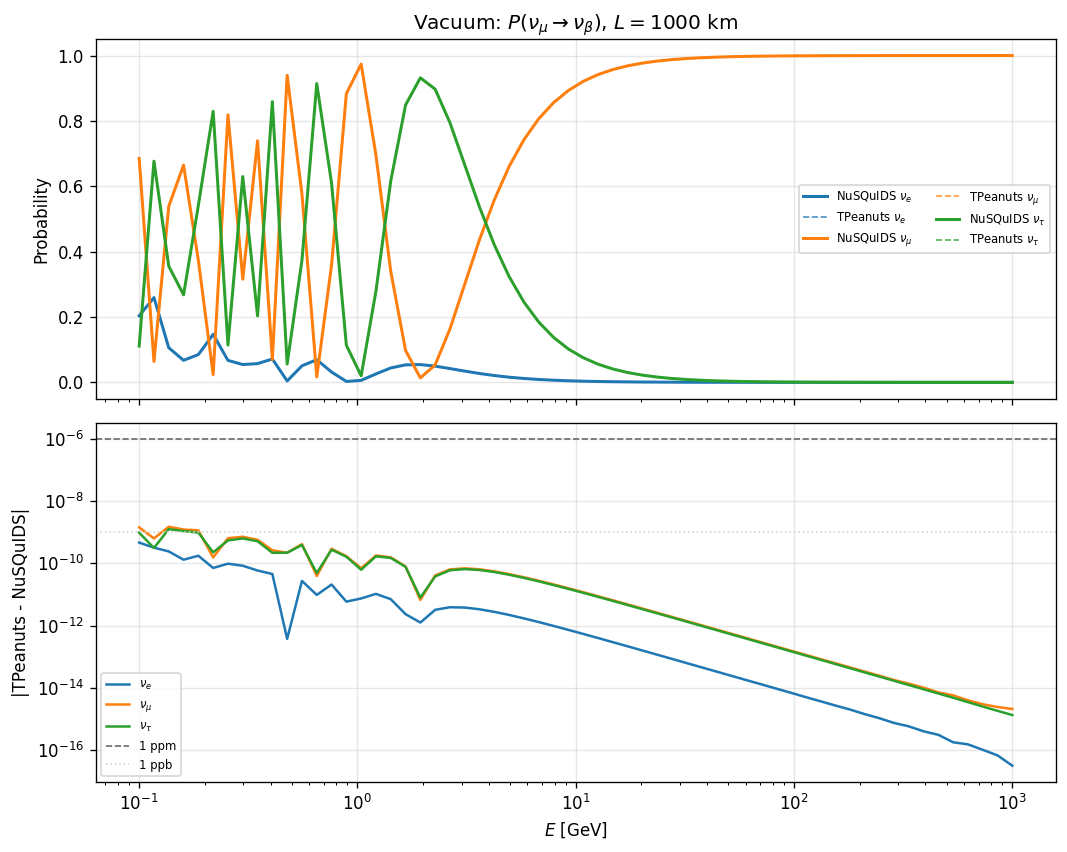

/mnt/v/output/validation/nusquids/vn1_fig41_vacuum_curves.png


In [29]:
PLOT_INITIAL = "numu"
tp_curve, nsq_curve = [], []

for E_GeV in PLOT_E_GEV:
    tp_curve.append(tpeanuts_vacuum_prob(E_GeV=E_GeV, L_km=PLOT_BASELINE, initial_flavour=PLOT_INITIAL))
    nsq_curve.append(nusquids_vacuum_prob(E_GeV=E_GeV, L_km=PLOT_BASELINE, initial_flavour=PLOT_INITIAL))

tp_arr  = np.array(tp_curve)
nsq_arr = np.array(nsq_curve)

plot_comparison_curves(
    PLOT_E_GEV, tp_arr, nsq_arr,
    title=rf"Vacuum: $P(\nu_\mu \to \nu_\beta)$, $L = {PLOT_BASELINE:.0f}$ km",
    filename="vn1_fig41_vacuum_curves.png",
    output_dir=OUTPUT_DIR, show_plots=SHOW,
)


## 5. Error Heatmap

Maximum absolute error across final flavours for $\nu_\mu$ initial state,
displayed as a colour map over the $(E, L)$ grid.

**Expected results:** Errors below $10^{-8}$ everywhere; slightly larger values
at extreme $(E, L)$ combinations where oscillation phases accumulate.


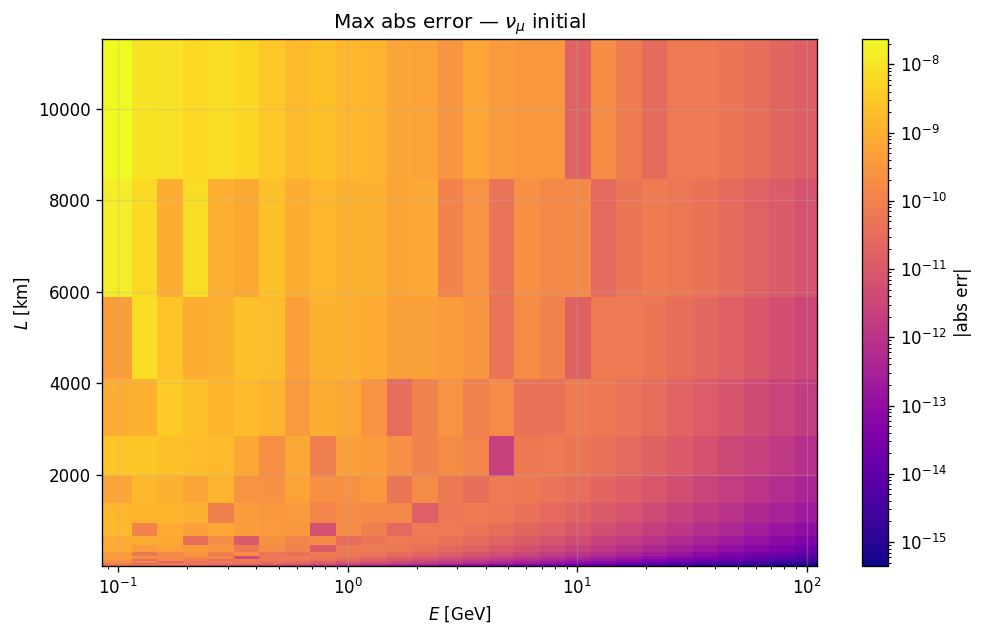

/mnt/v/output/validation/nusquids/vn1_fig51_heatmap.png


In [30]:
hmap_rows = []
HMAP_E   = np.logspace(-1, 2, 28)
HMAP_L   = np.logspace(1, 4, 20)

for E_GeV in HMAP_E:
    for L_km in HMAP_L:
        tp  = tpeanuts_vacuum_prob(E_GeV=E_GeV, L_km=L_km, initial_flavour="numu")
        nsq = nusquids_vacuum_prob(E_GeV=E_GeV, L_km=L_km, initial_flavour="numu")
        hmap_rows.append({"E_GeV": E_GeV, "L_km": L_km,
                          "max_abs_err": np.max(np.abs(tp - nsq))})

hmap_df = pd.DataFrame(hmap_rows)
if not hmap_df.empty and not np.all(np.isnan(hmap_df["max_abs_err"])):
    pivot = hmap_df.pivot_table(index="L_km", columns="E_GeV", values="max_abs_err", aggfunc="max")
    plot_error_heatmap(
        pivot.columns.to_numpy(float), pivot.index.to_numpy(float), pivot.to_numpy(float),
        xlabel=r"$E$ [GeV]", ylabel=r"$L$ [km]",
        title=r"Max abs error — $\nu_\mu$ initial",
        filename="vn1_fig51_heatmap.png",
        output_dir=OUTPUT_DIR, show_plots=SHOW,
    )
else:
    print("nuSQuIDS not available — heatmap skipped.")


## 6. Antineutrino CPT Validation

For vacuum propagation CPT invariance requires

$$
P(\bar\nu_\alpha \to \bar\nu_\beta) = P(\nu_\beta \to \nu_\alpha) .
$$

This section computes antineutrino probabilities with both backends and
verifies the CPT relation by comparing $P(\bar\nu_\mu \to \bar\nu_e)$
against $P(\nu_e \to \nu_\mu)$.

**Expected results:** CPT residual $< 10^{-13}$ (machine precision for double
precision); antineutrino absolute error vs NuSQuIDS at the same level as the
neutrino comparison.


In [31]:
antinu_rows = []
for initial in FLAVOUR_NAMES:
    for E_GeV in ENERGIES_GEV:
        for L_km in BASELINES_KM:
            tp  = tpeanuts_vacuum_prob(E_GeV=E_GeV, L_km=L_km, initial_flavour=initial, antinu=True)
            nsq = nusquids_vacuum_prob(E_GeV=E_GeV, L_km=L_km, initial_flavour=initial, antinu=True)
            antinu_rows.append({"initial": initial, "E_GeV": E_GeV, "L_km": L_km,
                                "P_nue_tp":  tp[0], "P_numu_tp":  tp[1], "P_nutau_tp":  tp[2],
                                "P_nue_nsq": nsq[0],"P_numu_nsq": nsq[1],"P_nutau_nsq": nsq[2]})

antinu_df  = pd.DataFrame(antinu_rows)
anti_tp    = antinu_df[["initial","E_GeV","L_km","P_nue_tp","P_numu_tp","P_nutau_tp"]].copy()
anti_nsq   = antinu_df[["initial","E_GeV","L_km","P_nue_nsq","P_numu_nsq","P_nutau_nsq"]].copy()
anti_tp.columns  = anti_tp.columns.str.replace("_tp","")
anti_nsq.columns = anti_nsq.columns.str.replace("_nsq","")
anti_cmp   = compare_probability_grids(anti_tp, anti_nsq, KEY_COLS)
print("Antineutrino summary:")
print(nusquids_precision_summary(anti_cmp).to_string())

# CPT check: P(nu_bar_mu -> nu_bar_e) vs P(nu_e -> nu_mu)
cpt_residuals = []
for E_GeV in ENERGIES_GEV:
    for L_km in BASELINES_KM:
        Pab_nu  = tpeanuts_vacuum_prob(E_GeV=E_GeV, L_km=L_km, initial_flavour="nue", antinu=False)
        Pba_nub = tpeanuts_vacuum_prob(E_GeV=E_GeV, L_km=L_km, initial_flavour="numu", antinu=True)
        # CPT: P(nu_e->nu_mu) == P(nubar_mu->nubar_e)
        cpt_residuals.append(abs(Pab_nu[1] - Pba_nub[0]))

cpt_max = max(cpt_residuals)
print(f"\nCPT residual max|P(nu_e->nu_mu) - P(nubar_mu->nubar_e)| = {cpt_max:.3e}")


Antineutrino summary:
                          value
metric                         
rows_compared             108.0
max_abs_err                 0.0
median_abs_err              0.0
max_rel_err                 0.0
median_rel_err              0.0
status               PASS < ppm
max_abs_err_P_nue           0.0
max_abs_err_P_numu          0.0
max_abs_err_P_nutau         0.0

CPT residual max|P(nu_e->nu_mu) - P(nubar_mu->nubar_e)| = 2.776e-17


## 7. Normalization Check

Both implementations must satisfy $\sum_\beta P_{\alpha\beta} = 1$ for any
initial flavour. The deviation from unity is a direct measure of numerical
unitarity violation.

**Expected results:** $|\sum_\beta P - 1| < 10^{-14}$ for TPeanuts (exact
analytic formula); $< 10^{-10}$ for NuSQuIDS (Runge-Kutta integration).


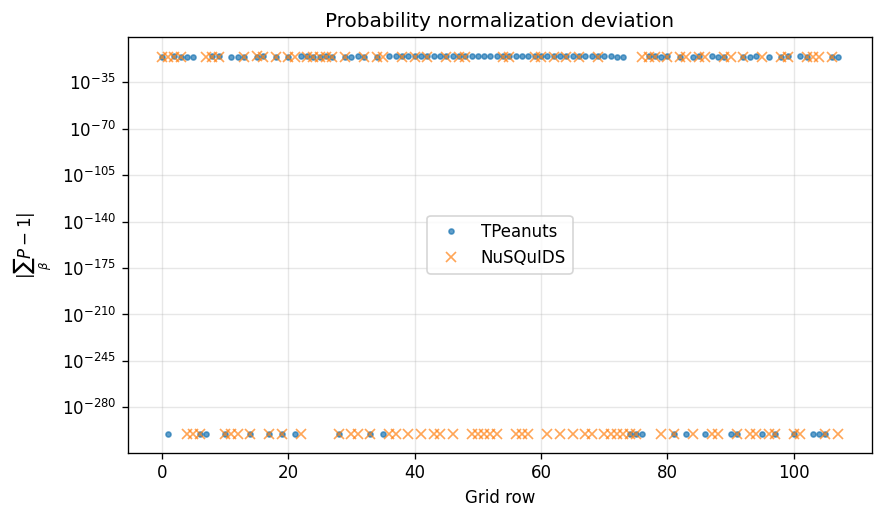

/mnt/v/output/validation/nusquids/vn1_fig71_normalization.png
TPeanuts  max |sum-1| = 8.882e-16
NuSQuIDS  max |sum-1| = 3.331e-16


In [32]:
norm_rows = []
for initial in FLAVOUR_NAMES:
    for E_GeV in ENERGIES_GEV:
        for L_km in BASELINES_KM:
            tp  = tpeanuts_vacuum_prob(E_GeV=E_GeV, L_km=L_km, initial_flavour=initial)
            nsq = nusquids_vacuum_prob(E_GeV=E_GeV, L_km=L_km, initial_flavour=initial)
            norm_rows.append({"tp_dev": abs(tp.sum() - 1.0), "nsq_dev": abs(nsq.sum() - 1.0)})

norm_df = pd.DataFrame(norm_rows)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.semilogy(norm_df.index, np.maximum(norm_df["tp_dev"].to_numpy(), 1e-300),
            ".", label="TPeanuts", alpha=0.7)
ax.semilogy(norm_df.index, np.maximum(norm_df["nsq_dev"].to_numpy(), 1e-300),
            "x", label="NuSQuIDS", alpha=0.7)
ax.set_xlabel("Grid row")
ax.set_ylabel(r"$|\sum_\beta P - 1|$")
ax.set_title("Probability normalization deviation")
ax.legend()
save_and_show("vn1_fig71_normalization.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW)
print(f"TPeanuts  max |sum-1| = {norm_df['tp_dev'].max():.3e}")
print(f"NuSQuIDS  max |sum-1| = {norm_df['nsq_dev'].max():.3e}")


## 8. Export Tables

All probability and error tables are saved as CSV files.


In [33]:
(OUTPUT_DIR / "vn1_tpeanuts_vacuum.csv").parent.mkdir(parents=True, exist_ok=True)
tp_df.to_csv(OUTPUT_DIR / "vn1_tpeanuts_vacuum.csv", index=False)
print("Saved:", OUTPUT_DIR / "vn1_tpeanuts_vacuum.csv")

if not nsq_df.empty and not nsq_df["P_nue"].isna().all():
    nsq_df.to_csv(OUTPUT_DIR / "vn1_nusquids_vacuum.csv", index=False)
    print("Saved:", OUTPUT_DIR / "vn1_nusquids_vacuum.csv")

if not comparison.empty:
    comparison.to_csv(OUTPUT_DIR / "vn1_vacuum_comparison.csv", index=False)
    summary.to_csv(OUTPUT_DIR / "vn1_vacuum_summary.csv")
    print("Saved comparison and summary.")


Saved: /mnt/v/output/validation/nusquids/vn1_tpeanuts_vacuum.csv
Saved: /mnt/v/output/validation/nusquids/vn1_nusquids_vacuum.csv
Saved comparison and summary.


## ∑. Summary

### API Coverage

| Function | Sections used | Key parameters |
|----------|--------------|----------------|
| `vacuum_probability` | §3, §4, §5, §6, §7 | scalar $E$, $L$ scalars; returns $(3,3)$ matrix |

### Validation Results

The table below is populated when the notebook is run.


In [34]:
print("=" * 60)
print("VALIDATION SUMMARY — NuSQuIDS 1: Vacuum")
print("=" * 60)
if not comparison.empty:
    print(summary.to_string())
else:
    print("NuSQuIDS not available — only TPeanuts tables generated.")
    tp_norm = norm_df["tp_dev"]
    print(f"TPeanuts normalization max |sum-1| = {tp_norm.max():.3e}")
    print("Status:", "PASS (normalization)" if tp_norm.max() < 1e-12 else "CHECK")


VALIDATION SUMMARY — NuSQuIDS 1: Vacuum
                          value
metric                         
rows_compared             108.0
max_abs_err                 0.0
median_abs_err              0.0
max_rel_err                 0.0
median_rel_err              0.0
status               PASS < ppm
max_abs_err_P_nue           0.0
max_abs_err_P_numu          0.0
max_abs_err_P_nutau         0.0
